# Bank Marketing — Assignment 2 (Colab)

M.Tech (AIML/DSE) — Machine Learning — Assignment 2

This notebook trains and evaluates 5 classification models on the UCI
**Bank Marketing** dataset (`bank-additional-full.csv`):
1. Logistic Regression
2. Decision Tree Classifier
3. K-Nearest Neighbor Classifier
4. Gaussian Naive Bayes
5. Random Forest (Ensemble)

For each model it computes: **Accuracy, AUC, Precision, Recall, F1, MCC**,
and saves the fitted pipelines (`.pkl`) plus a held-out `test_data.csv` you
can later upload to the Streamlit app.

**Note:** the `duration` column is dropped before training — it's a known
data-leakage feature (only known *after* a call ends), so keeping it
would give unrealistically inflated metrics for a model that's supposed
to help decide *whom to call*.

**How to run in Colab:** Runtime → Run all. When prompted, upload
`bank_marketing.csv` (Step 2 below).

## 1. Install / import libraries

In [1]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn ucimlrepo

import json
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, matthews_corrcoef, precision_score,
    recall_score, roc_auc_score, confusion_matrix, classification_report,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

import os
os.makedirs("model", exist_ok=True)

## 2. Load the dataset

Fetches the **Bank Marketing** dataset directly from the UCI Machine
Learning Repository (dataset id `222`) using the official `ucimlrepo`
client — no manual upload needed. Falls back to a local
`bank_marketing.csv` if UCI can't be reached (e.g. no internet, or a
sandboxed environment).

In [2]:
from ucimlrepo import fetch_ucirepo

try:
    bank_marketing = fetch_ucirepo(id=222)
    X_raw = bank_marketing.data.features
    y_raw = bank_marketing.data.targets
    df = pd.concat([X_raw, y_raw], axis=1)
    print("Fetched directly from UCI Machine Learning Repository (id=222)")
except Exception as e:
    print(f"Could not reach UCI ({e}); falling back to local CSV.")
    df = pd.read_csv("bank_marketing.csv", sep=";")

print(df.shape)
df.head()

Saving bank_marketing.csv to bank_marketing.csv
(41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 3. Explore the data

In [3]:
df.info()
print()
print(df['y'].value_counts())
print()
print("Missing values:", df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

## 4. Preprocessing

In [4]:
# Drop 'duration' - known data leakage feature (see intro note above)
df = df.drop(columns=["duration"])

TARGET = "y"
df[TARGET] = df[TARGET].map({"yes": 1, "no": 0})

X = df.drop(columns=[TARGET])
y = df[TARGET]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

test_export = X_test.copy()
test_export[TARGET] = y_test.values
test_export.to_csv("test_data.csv", index=False)
print("Saved test_data.csv with", len(test_export), "rows")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

Numeric features: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Saved test_data.csv with 8238 rows


## 5. Define the 5 models

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=10),
    "kNN": KNeighborsClassifier(n_neighbors=7),
    "Naive Bayes": GaussianNB(),
    "Random Forest (Ensemble)": RandomForestClassifier(
        n_estimators=150, max_depth=12, random_state=RANDOM_STATE
    ),
}

## 6. Train, evaluate, and save each model

In [6]:
results = []
fitted_pipelines = {}

for name, clf in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", clf)])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "MCC": matthews_corrcoef(y_test, y_pred),
    }
    results.append(metrics)
    fitted_pipelines[name] = pipe

    safe_name = name.lower().replace(" ", "_").replace("(", "").replace(")", "")
    with open(f"model/{safe_name}.pkl", "wb") as f:
        pickle.dump(pipe, f)

    print(f"\n{name}")
    for k, v in metrics.items():
        if k != "Model":
            print(f"  {k}: {v:.4f}")

results_df = pd.DataFrame(results).set_index("Model").round(4)
results_df.to_csv("model/metrics_comparison.csv")

schema = {
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "target": TARGET,
}
with open("model/schema.json", "w") as f:
    json.dump(schema, f, indent=2)

print("\nAll models trained and saved to model/ folder.")


Logistic Regression
  Accuracy: 0.9009
  AUC: 0.8008
  Precision: 0.6905
  Recall: 0.2188
  F1: 0.3322
  MCC: 0.3516

Decision Tree
  Accuracy: 0.9013
  AUC: 0.7581
  Precision: 0.6353
  Recall: 0.2909
  F1: 0.3991
  MCC: 0.3856

kNN
  Accuracy: 0.8996
  AUC: 0.7613
  Precision: 0.6145
  Recall: 0.2920
  F1: 0.3959
  MCC: 0.3775

Naive Bayes
  Accuracy: 0.8049
  AUC: 0.7755
  Precision: 0.3172
  Recall: 0.6347
  F1: 0.4230
  MCC: 0.3490

Random Forest (Ensemble)
  Accuracy: 0.9020
  AUC: 0.8116
  Precision: 0.6817
  Recall: 0.2446
  F1: 0.3600
  MCC: 0.3694

All models trained and saved to model/ folder.


## 7. Comparison table

In [7]:
results_df.style.highlight_max(axis=0, color="#c6f6d5")

,Accuracy,AUC,Precision,Recall,F1,MCC
Model,,,,,,
Logistic Regression,0.900900,0.800800,0.690500,0.218800,0.332200,0.351600
Decision Tree,0.901300,0.758100,0.635300,0.290900,0.399100,0.385600
kNN,0.899600,0.761300,0.614500,0.292000,0.395900,0.377500
Naive Bayes,0.804900,0.775500,0.317200,0.634700,0.423000,0.349000
Random Forest (Ensemble),0.902000,0.811600,0.681700,0.244600,0.360000,0.369400


## 8. Visualize: metric comparison bar chart

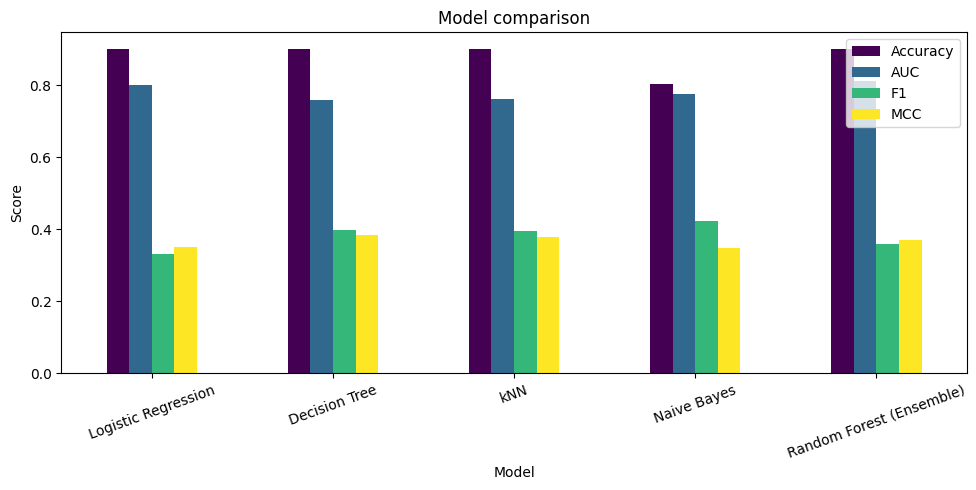

In [8]:
results_df[["Accuracy", "AUC", "F1", "MCC"]].plot(
    kind="bar", figsize=(10, 5), rot=20, colormap="viridis"
)
plt.title("Model comparison")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

## 9. Confusion matrices for all 5 models

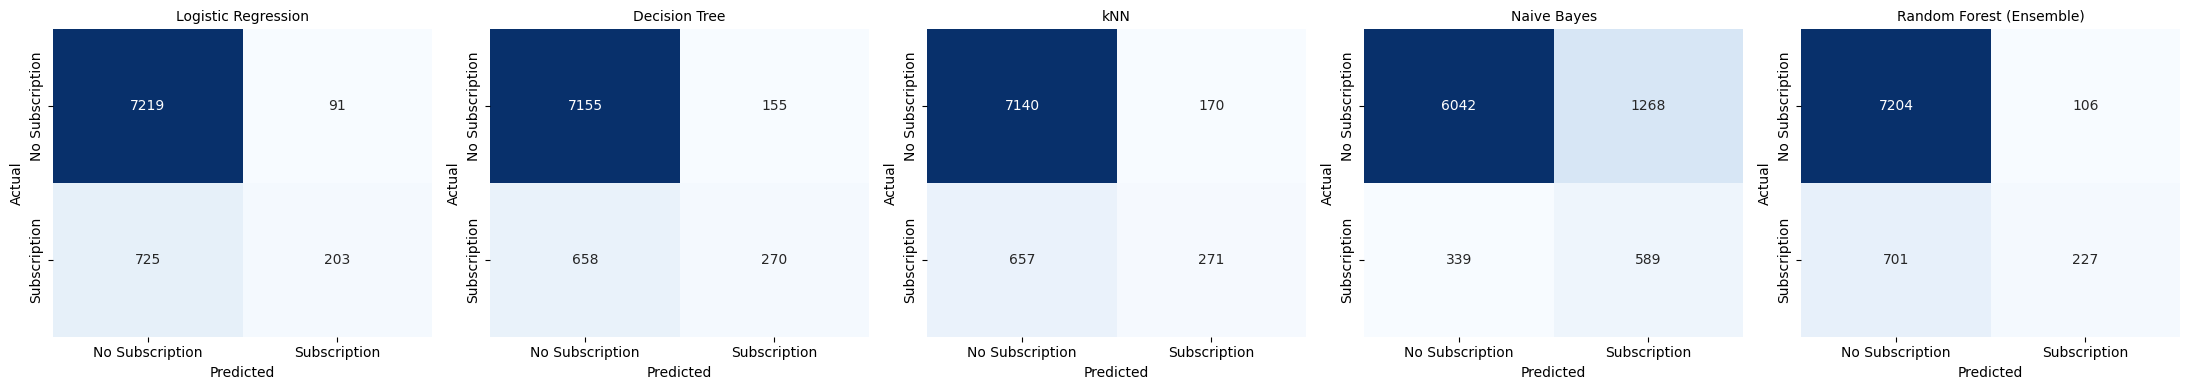

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, pipe) in zip(axes, fitted_pipelines.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["No Subscription", "Subscription"],
                yticklabels=["No Subscription", "Subscription"])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 10. Download artifacts (Colab only)

Zips up the `model/` folder + `test_data.csv` so you can download them
and push to your GitHub repo alongside `app.py`.

In [10]:
import shutil

shutil.make_archive("assignment2_artifacts", "zip", ".", "model")

try:
    from google.colab import files
    files.download("assignment2_artifacts.zip")
    files.download("test_data.csv")
except ImportError:
    print("Not running in Colab — files are already saved locally in this folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Next steps

1. Download `assignment2_artifacts.zip` (contains the `model/` folder) and `test_data.csv`.
2. Combine with `app.py`, `requirements.txt`, `runtime.txt`, and `README.md` from the project package.
3. Push everything to a public GitHub repo.
4. Deploy `app.py` on Streamlit Community Cloud.
5. Test the live app by uploading `test_data.csv`.